In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("bhavikjikadara/dog-and-cat-classification-dataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/bhavikjikadara/dog-and-cat-classification-dataset


Corrupt JPEG data: 239 extraneous bytes before marker 0xd9


✅ Accuracy: 67.50%


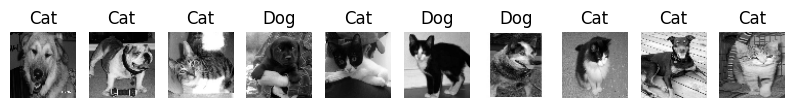

In [13]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Correct dataset path
DATADIR = "/kaggle/input/datasets/bhavikjikadara/dog-and-cat-classification-dataset/PetImages"
categories = ["Cat", "Dog"]

data = []

# Load images
for category in categories:

    path = os.path.join(DATADIR, category)
    label = categories.index(category)

    # Use only 50 images
    for img in os.listdir(path)[:200]:

        try:
            img_path = os.path.join(path, img)

            image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

            image = cv2.resize(image, (64,64))

            data.append([image, label])

        except:
            pass

# Prepare data
X = []
y = []

for features, label in data:
    X.append(features)
    y.append(label)

X = np.array(X).reshape(len(X), -1)
y = np.array(y)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train SVM model
model = SVC()

model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print(f"✅ Accuracy: {accuracy*100:.2f}%")

# Display predictions
plt.figure(figsize=(10,5))

for i in range(10):

    plt.subplot(1,10,i+1)

    img = X_test[i].reshape(64,64)

    plt.imshow(img, cmap='gray')

    prediction = "Dog" if y_pred[i] == 1 else "Cat"

    plt.title(prediction)

    plt.axis("off")

plt.show()